
# Employee Financial Behaviour & Desired Savings Prediction — Extended Analysis Notebook

This notebook extends the existing workflow by **adding richer preprocessing diagnostics and analysis charts**
while keeping the **original modeling flow unchanged**.

Additional sections include:

## Data Quality Checks
- Missing value inspection
- Duplicate detection
- Outlier analysis
- Feature distribution before preprocessing

## Preprocessing Enhancements
- Missing value imputation
- Standardization comparison (before vs after)
- PCA dimensionality reduction
- PCA component contribution heatmap

## Model Evaluation Enhancements
- R² score visualization
- Residual analysis
- Actual vs predicted scatter plot

## Classification-style Evaluation
- Confusion matrix
- ROC curve
- Sigmoid function visualization

## Exploratory Visualizations
- Feature histogram grid
- Correlation heatmap
- PCA scatter visualization


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.metrics import confusion_matrix, roc_curve, auc

import joblib


## Load Dataset

In [2]:

df = pd.read_csv(r"C:\Users\antor\Downloads\financial_data.csv");
df.head()


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49.0,0.0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34.0,2.0,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35.0,1.0,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21.0,0.0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52.0,4.0,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


## Dataset Structure

In [3]:

print("Shape:", df.shape)
print("Columns:", df.columns)
df.info()


Shape: (20600, 27)
Columns: Index(['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent',
       'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out',
       'Entertainment', 'Utilities', 'Healthcare', 'Education',
       'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings',
       'Disposable_Income', 'Potential_Savings_Groceries',
       'Potential_Savings_Transport', 'Potential_Savings_Eating_Out',
       'Potential_Savings_Entertainment', 'Potential_Savings_Utilities',
       'Potential_Savings_Healthcare', 'Potential_Savings_Education',
       'Potential_Savings_Miscellaneous'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 20600 entries, 0 to 20599
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           19558 non-null  float64
 1   Age                              19570 non-null  float64
 2  

## Missing Values Analysis

Income                             1042
Age                                1030
Dependents                         1042
Occupation                         1022
City_Tier                          1021
Rent                               1042
Loan_Repayment                        0
Insurance                             0
Groceries                             0
Transport                             0
Eating_Out                            0
Entertainment                         0
Utilities                             0
Healthcare                            0
Education                             0
Miscellaneous                         0
Desired_Savings_Percentage            0
Desired_Savings                       0
Disposable_Income                     0
Potential_Savings_Groceries           0
Potential_Savings_Transport           0
Potential_Savings_Eating_Out          0
Potential_Savings_Entertainment       0
Potential_Savings_Utilities           0
Potential_Savings_Healthcare          0


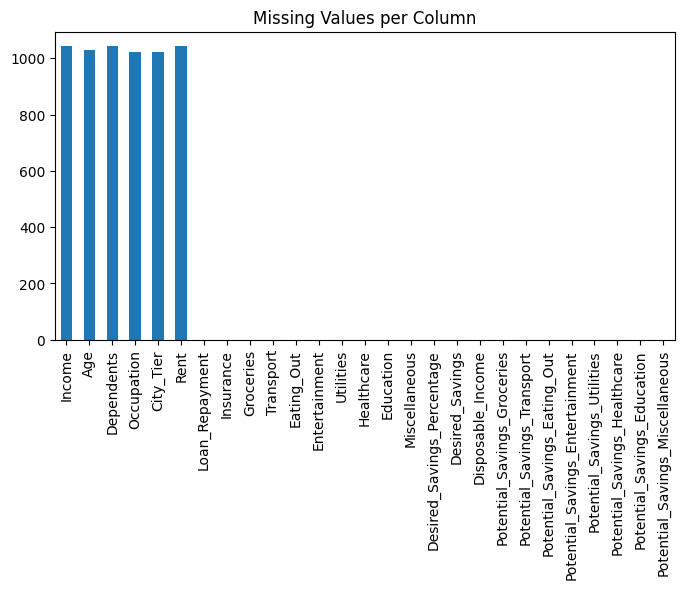

In [4]:

missing = df.isnull().sum()
print(missing)

plt.figure(figsize=(8,4))
missing.plot(kind="bar")
plt.title("Missing Values per Column")
plt.show()


## Handle Missing Values

In [5]:

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


C:\Users\antor\AppData\Local\Temp\ipykernel_13308\1755004075.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mode()[0], inplace=True)


## Duplicate Detection

In [6]:

duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()


Duplicate rows: 540


## Feature Distribution (Before Standardization)

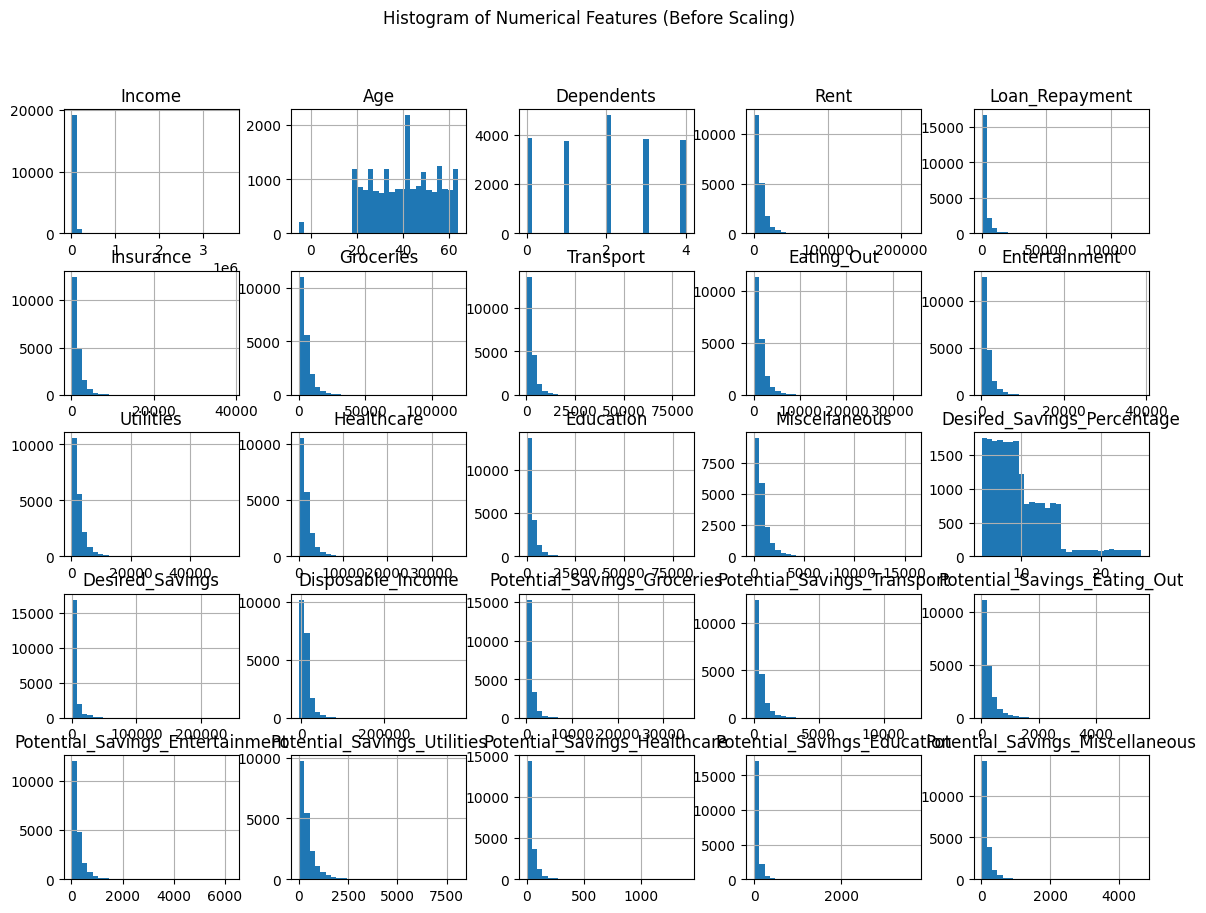

In [7]:

df.select_dtypes(include=np.number).hist(figsize=(14,10), bins=30)
plt.suptitle("Histogram of Numerical Features (Before Scaling)")
plt.show()


## Correlation Heatmap

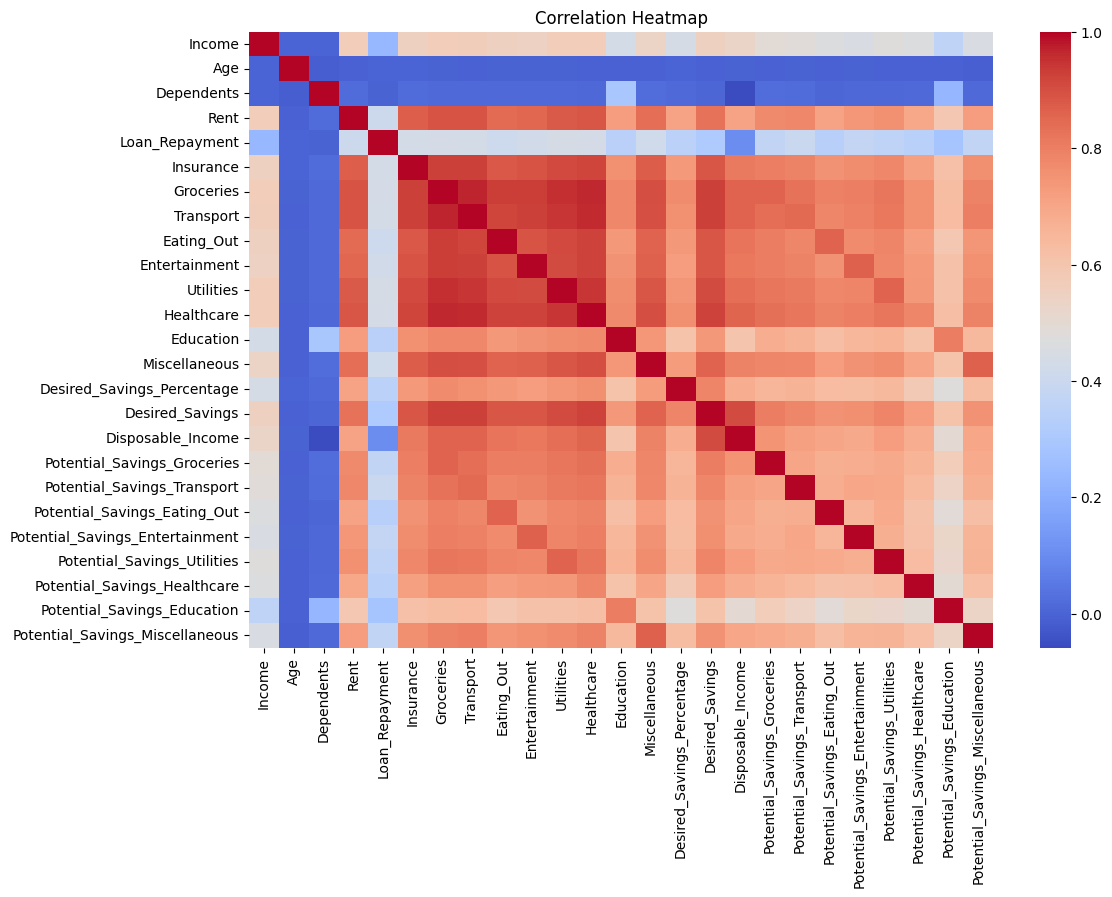

In [8]:

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## Target Distribution

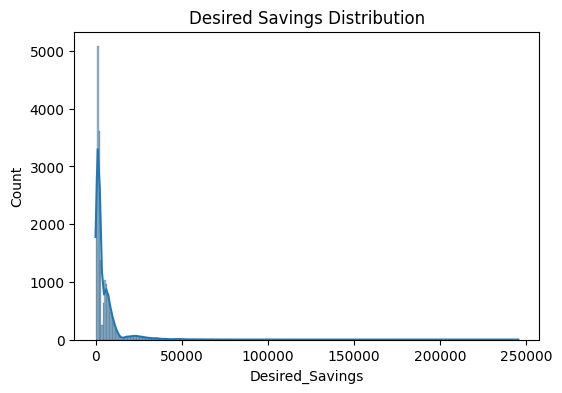

In [9]:

plt.figure(figsize=(6,4))
sns.histplot(df["Desired_Savings"], kde=True)
plt.title("Desired Savings Distribution")
plt.show()


## Feature Engineering

In [10]:

expense_cols = [
"Rent","Loan_Repayment","Insurance","Groceries","Transport",
"Eating_Out","Entertainment","Utilities","Healthcare","Education","Miscellaneous"
]

df["Total_Expense"] = df[expense_cols].sum(axis=1)
df["Expense_Income_Ratio"] = df["Total_Expense"] / df["Income"]
df["Per_Dependent_Expense"] = df["Total_Expense"] / (df["Dependents"] + 1)


## Feature Selection

In [11]:

X = df.drop(["Desired_Savings","Desired_Savings_Percentage","Disposable_Income"], axis=1)
df["Financial_Risk"] = (df["Expense_Income_Ratio"] > 0.7).astype(int)
y = df["Financial_Risk"]


## Train Test Split

In [12]:

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)


## Standardization

In [13]:

numeric_train = X_train.select_dtypes(include=np.number)
numeric_test = X_test.select_dtypes(include=np.number)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(numeric_train)
X_test_scaled = scaler.transform(numeric_test)


## Distribution After Standardization

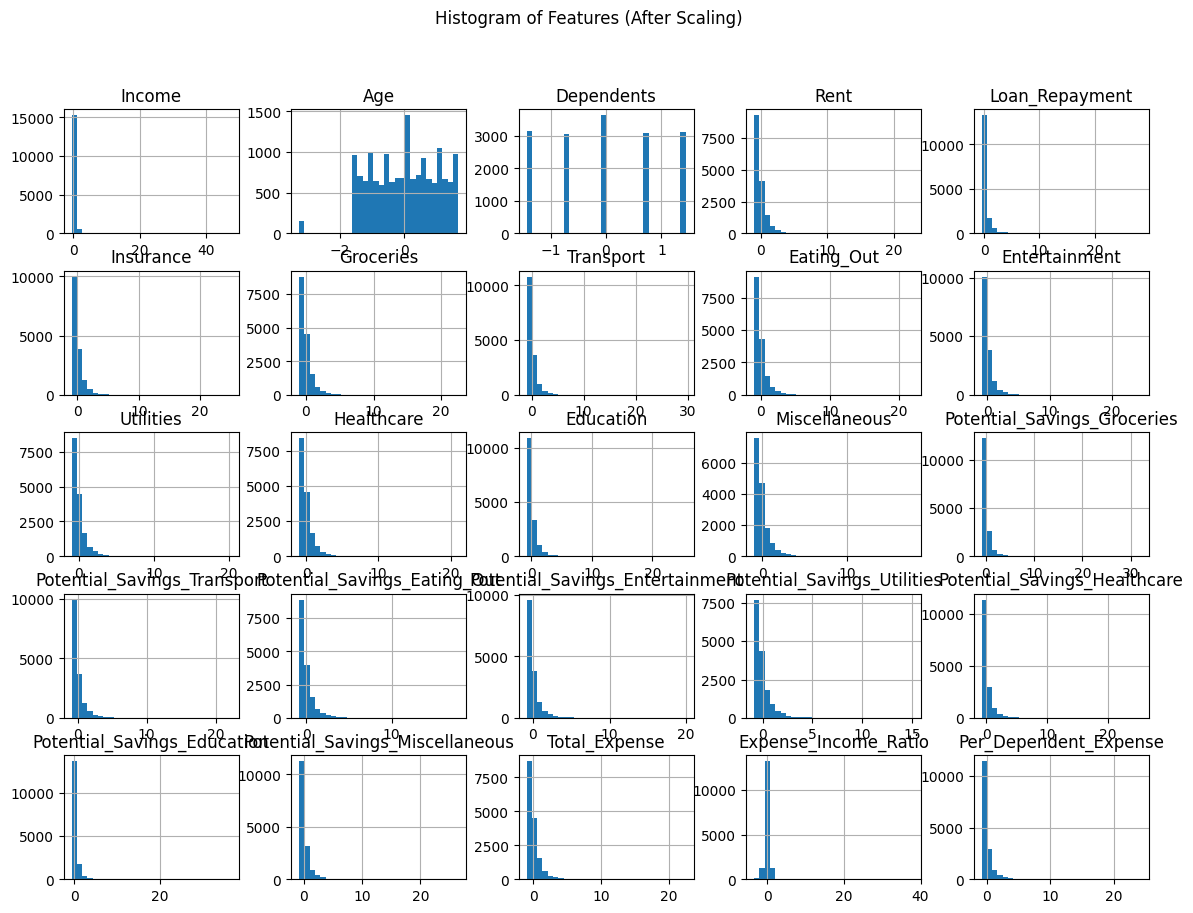

In [14]:

scaled_df = pd.DataFrame(X_train_scaled, columns=numeric_train.columns)

scaled_df.hist(figsize=(14,10), bins=30)
plt.suptitle("Histogram of Features (After Scaling)")
plt.show()


## PCA Dimensionality Reduction

In [15]:

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.64803387 0.06546647 0.04906139 0.04000987 0.02968207]


## PCA Explained Variance Plot

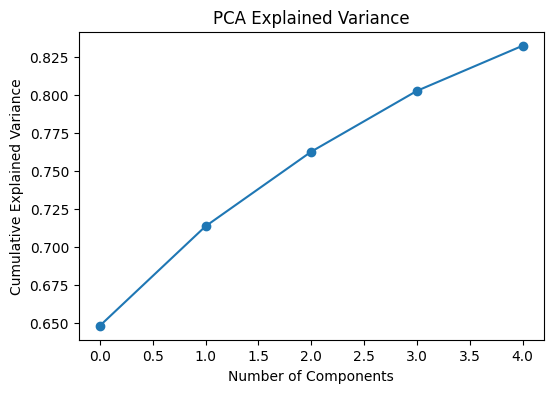

In [16]:

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()


## PCA Feature Contribution Heatmap

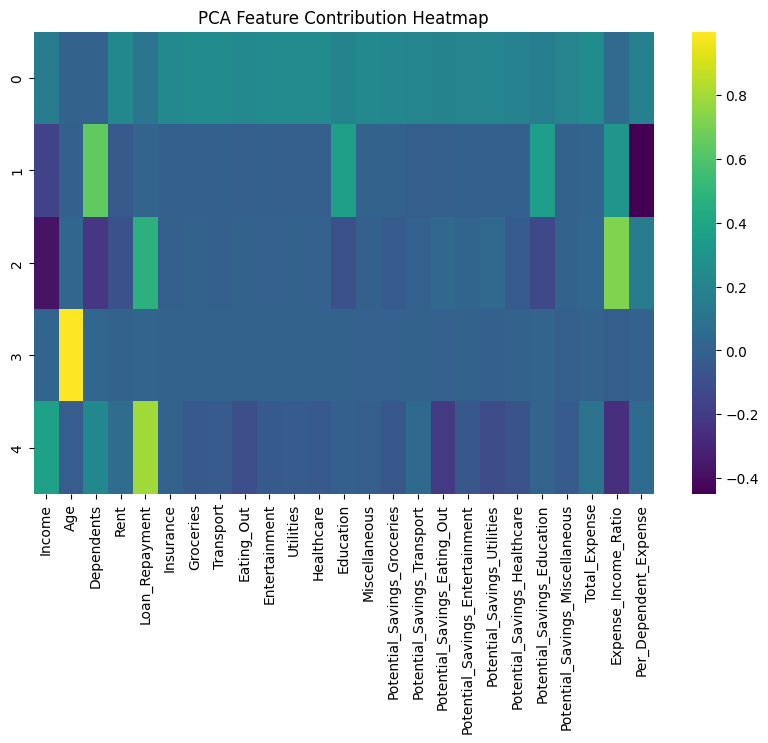

In [17]:

pca_df = pd.DataFrame(
pca.components_,
columns=numeric_train.columns
)

plt.figure(figsize=(10,6))
sns.heatmap(pca_df, cmap="viridis")
plt.title("PCA Feature Contribution Heatmap")
plt.show()


## PCA Scatter Visualization

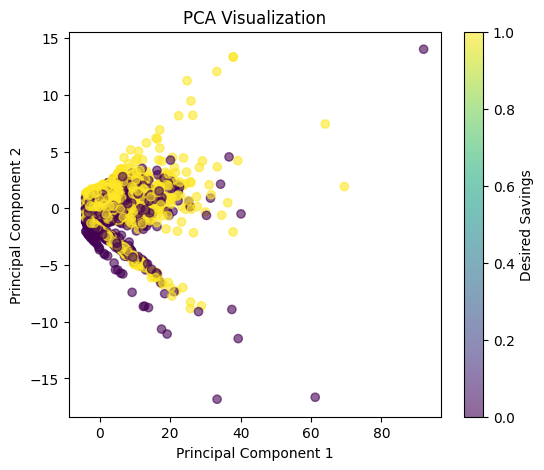

In [18]:

plt.figure(figsize=(6,5))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.colorbar(label="Desired Savings")

plt.show()


## Train Linear Regression Model

In [19]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Predictions

In [20]:

y_pred = model.predict(X_test_pca)


## Model Evaluation Metrics

In [22]:
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
import numpy as np

r2 = accuracy_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9456630109670987
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1578
           1       0.96      0.95      0.96      2434

    accuracy                           0.95      4012
   macro avg       0.94      0.94      0.94      4012
weighted avg       0.95      0.95      0.95      4012



## Actual vs Predicted Plot

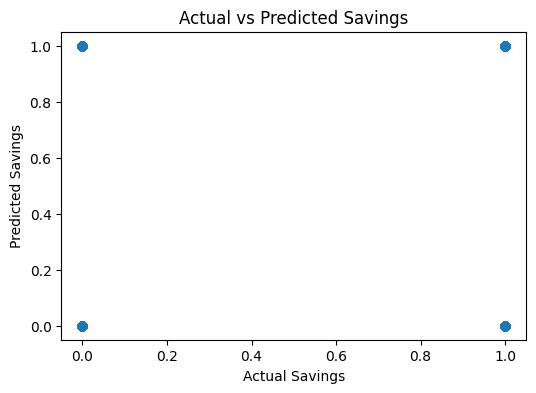

In [23]:

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Savings")
plt.ylabel("Predicted Savings")
plt.title("Actual vs Predicted Savings")
plt.show()


## Residual Analysis

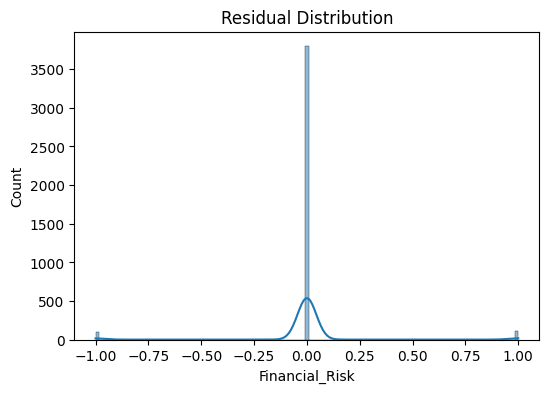

In [24]:

residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


## Confusion Matrix & ROC (Savings Category)

c:\Users\antor\DS_EL\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


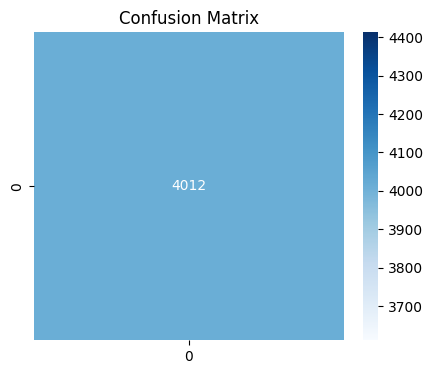

c:\Users\antor\DS_EL\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


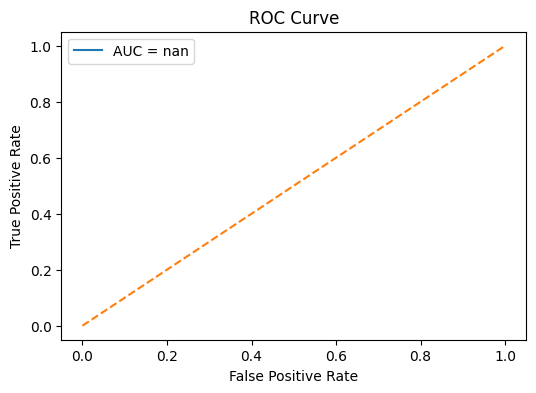

In [25]:

threshold = y.median()

y_true_class = (y_test > threshold).astype(int)
y_pred_class = (y_pred > threshold).astype(int)

cm = confusion_matrix(y_true_class, y_pred_class)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_true_class, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Sigmoid Function Visualization

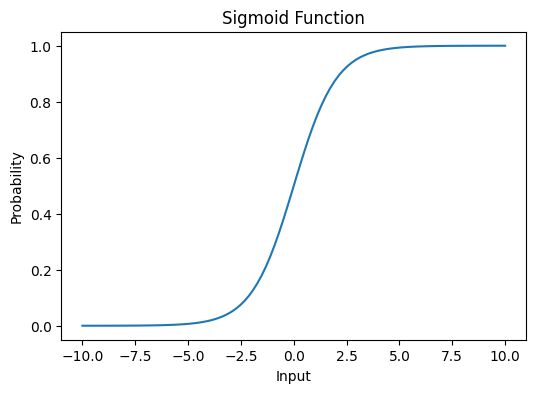

In [26]:

x = np.linspace(-10,10,100)
y_sig = 1/(1+np.exp(-x))

plt.figure(figsize=(6,4))
plt.plot(x,y_sig)
plt.title("Sigmoid Function")
plt.xlabel("Input")
plt.ylabel("Probability")
plt.show()


## Save Model Files

In [27]:

joblib.dump(model,"savings_model.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(pca,"pca.pkl")

print("Model files saved for Streamlit.")


Model files saved for Streamlit.
